# F1 Tyre Degradation Predictor

End-to-end notebook: fetch lap data → engineer features → train LSTM or linear baseline → evaluate.

**Sections**
1. Imports & configuration
2. Data fetching (via FastF1)
3. Feature engineering & dataset building
4. Model definitions (LSTM + Linear baseline)
5. Training & evaluation
6. Results summary

## 1 · Imports & Configuration

In [86]:
# ── standard library ──────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

# ── third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import fastf1

print(f"torch  : {torch.__version__}")
print(f"fastf1 : {fastf1.__version__}")
print(f"device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

torch  : 2.3.1+cu121
fastf1 : 3.3.9
device : cuda


In [87]:
# ── global config (edit here) ─────────────────────────────────────────────────
CACHE_DIR        = "fastf1_cache"
PARQUET_PATH     = "laps.parquet"

FETCH_YEARS      = [2019, 2020, 2021, 2023, 2024]  # 2022 skipped (API rate-limit during fetch)
SCHEDULE_LIMIT   = None           # set to e.g. 3 for a quick smoke-test

MODEL_TYPE       = "lstm"         # "lstm" | "linear"
EPOCHS           = 60             # upper bound; early stopping will cut this short
BATCH_SIZE       = 128
LR               = 1e-3
WEIGHT_DECAY     = 1e-4           # L2 regularisation for Adam
SEED             = 0

# data-prep outlier filter (applied at fetch time and when building from scratch)
DEG_MIN_S        = -1.0           # small negatives ok (track evolution / reference noise)
DEG_MAX_S        = 10.0           # above this: traffic / SC anomalies

# LSTM architecture
LSTM_HIDDEN_DIM  = 64
LSTM_NUM_LAYERS  = 4      # stack a second LSTM layer
LSTM_DROPOUT     = 0.2            # applied between stacked layers (ignored if num_layers=1)

# early stopping
EARLY_STOP_PATIENCE = 7           # stop if val RMSE doesn't improve for this many epochs

# feature / window constants
WINDOW           = 8              # captures a longer degradation history than the original 5
COMPOUNDS        = ["SOFT", "MEDIUM", "HARD"]
NUMERIC_FEATURES = ["TyreLife", "AirTemp", "TrackTemp", "Humidity", "Rainfall"]

# engineered features — derived from raw columns, z-scored together with NUMERIC_FEATURES
# TyreLifeSq: captures the non-linear acceleration of the degradation cliff
# *_TyreLife: compound×age interactions (Soft wears faster per lap than Hard)
# StintProgress: where in the stint we are (0→1), captures track-evolution baseline drift
DERIVED_FEATURES = [
    "TyreLifeSq",
    "SOFT_TyreLife", "MEDIUM_TyreLife", "HARD_TyreLife",
    "StintProgress",
]

FUEL_PER_LAP_S   = 0.03          # seconds of laptime benefit per lap of fuel burn

# street circuits — EventName keywords used to label circuit type for breakdown evaluation
STREET_CIRCUITS  = {"Monaco", "Singapore", "Azerbaijan", "Saudi", "Miami", "Las Vegas"}

# reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Config ready.")

Config ready.


## 2 · Data Fetching

Downloads race laps via FastF1.  
Results are cached to `./fastf1_cache`; subsequent runs are fast.

In [88]:
def fetch_session(year: int, round_number: int):
    """Load a race session (laps + weather, no telemetry)."""
    session = fastf1.get_session(year, round_number, "R")
    session.load(laps=True, telemetry=False, weather=True, messages=False)
    return session


def lap_records(session, year: int, round_number: int) -> pd.DataFrame:
    """Extract per-lap rows with fuel-corrected lap time and weather merge."""
    laps = session.laps.copy()
    if laps.empty:
        return pd.DataFrame()

    laps = laps.loc[
        laps["IsAccurate"].fillna(False)
        & laps["LapTime"].notna()
        & laps["PitInTime"].isna()
        & laps["PitOutTime"].isna()
        & laps["Compound"].isin(COMPOUNDS)
    ].copy()
    if laps.empty:
        return laps

    laps["LapTimeSec"]  = laps["LapTime"].dt.total_seconds()
    total_laps           = laps["LapNumber"].max()
    laps["FuelCorrLap"] = laps["LapTimeSec"] - (total_laps - laps["LapNumber"]) * FUEL_PER_LAP_S

    weather = session.weather_data
    if weather is not None and not weather.empty:
        weather = weather[["Time", "AirTemp", "TrackTemp", "Humidity", "Rainfall"]].sort_values("Time")
        laps = laps.sort_values("LapStartTime")
        laps = pd.merge_asof(
            laps, weather,
            left_on="LapStartTime", right_on="Time",
            direction="nearest",
        )
    else:
        for col in ["AirTemp", "TrackTemp", "Humidity", "Rainfall"]:
            laps[col] = np.nan

    laps["Year"]    = year
    laps["Round"]   = round_number
    laps["Circuit"] = session.event["EventName"]

    cols = [
        "Year", "Round", "Circuit", "Driver", "Stint", "LapNumber",
        "Compound", "TyreLife", "LapTimeSec", "FuelCorrLap",
        "AirTemp", "TrackTemp", "Humidity", "Rainfall",
    ]
    return pd.DataFrame(laps[cols])

In [89]:
def compute_degradation_target(df: pd.DataFrame) -> pd.DataFrame:
    """DegSec = fuel-corrected laptime minus the driver's fastest early-stint lap (TyreLife ≤ 3)."""
    df          = df.copy()
    stint_keys  = ["Year", "Round", "Driver", "Stint"]
    fresh = (
        df.loc[df["TyreLife"] <= 3]
        .groupby(stint_keys, as_index=False)["FuelCorrLap"]
        .min()
        .rename(columns={"FuelCorrLap": "StintBase"})
    )
    df = df.merge(fresh, on=stint_keys, how="left")
    df = df.dropna(subset=["StintBase"])
    df["DegSec"] = df["FuelCorrLap"] - df["StintBase"]
    return df


def build_dataset(years, schedule_limit=None) -> pd.DataFrame:
    rows = []
    for year in years:
        try:
            schedule = fastf1.get_event_schedule(year, include_testing=False)
        except Exception as e:
            print(f"failed to load schedule for {year}: {e}")
            continue
        if schedule_limit:
            schedule = schedule.head(schedule_limit)
        for _, ev in schedule.iterrows():
            rnd = int(ev["RoundNumber"])
            try:
                session = fetch_session(year, rnd)
                rows.append(lap_records(session, year, rnd))
                print(f"  loaded {year} R{rnd:02d} {ev['EventName']}")
            except Exception as e:
                print(f"  skip   {year} R{rnd:02d} {ev['EventName']}: {e}")
    if not rows:
        raise RuntimeError("no race data was loaded")
    df = pd.concat(rows, ignore_index=True)
    return compute_degradation_target(df)

In [90]:
# ── fetch or load from cache ──────────────────────────────────────────────────
if os.path.exists(PARQUET_PATH):
    print(f"Loading existing dataset from {PARQUET_PATH} …")
    raw_df = pd.read_parquet(PARQUET_PATH)
else:
    print(f"Fetching {FETCH_YEARS} (this may take a while on first run) …")
    raw_df = build_dataset(FETCH_YEARS, schedule_limit=SCHEDULE_LIMIT)
    raw_df.to_parquet(PARQUET_PATH)
    print(f"Saved {len(raw_df)} rows → {PARQUET_PATH}")

print(f"\nDataset shape : {raw_df.shape}")
raw_df.head()

Loading existing dataset from laps.parquet …

Dataset shape : (61856, 42)


,Year,Round,Circuit,Driver,Stint,LapNumber,Compound,TyreLife,LapTimeSec,FuelCorrLap,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,StintBase,DegSec
7,2019.0,1.0,Australian Grand Prix,HUL,1.0,2.0,SOFT,2.0,91.205,89.525,...,NaT,NaT,None,NaN,None,None,None,None,89.049,0.476
10,2019.0,1.0,Australian Grand Prix,ALB,1.0,2.0,SOFT,2.0,91.716,90.036,...,NaT,NaT,None,NaN,None,None,None,None,89.707,0.329
12,2019.0,1.0,Australian Grand Prix,STR,1.0,2.0,MEDIUM,2.0,92.014,90.334,...,NaT,NaT,None,NaN,None,None,None,None,89.908,0.426
13,2019.0,1.0,Australian Grand Prix,SAI,1.0,2.0,SOFT,2.0,92.340,90.660,...,NaT,NaT,None,NaN,None,None,None,None,89.817,0.843
14,2019.0,1.0,Australian Grand Prix,KVY,1.0,2.0,MEDIUM,2.0,92.335,90.655,...,NaT,NaT,None,NaN,None,None,None,None,89.843,0.812


## 3 · Feature Engineering & Windowing

In [91]:
def is_street(circuit: str) -> bool:
    return any(kw in circuit for kw in STREET_CIRCUITS)


def encode(df: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode compound and coerce numeric features."""
    df = df.copy()
    for c in COMPOUNDS:
        df[f"is_{c}"] = (df["Compound"] == c).astype(float)
    for c in NUMERIC_FEATURES:
        coerced = pd.to_numeric(df[c], errors="coerce")
        df[c] = pd.Series(coerced, index=df.index).fillna(0.0).astype(float)
    return df


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add non-linear and interaction features. Must be called after encode()
    so that is_SOFT / is_MEDIUM / is_HARD columns already exist."""
    df = df.copy()
    df["TyreLifeSq"]      = df["TyreLife"] ** 2
    df["SOFT_TyreLife"]   = df["is_SOFT"]   * df["TyreLife"]
    df["MEDIUM_TyreLife"] = df["is_MEDIUM"] * df["TyreLife"]
    df["HARD_TyreLife"]   = df["is_HARD"]   * df["TyreLife"]
    stint_max = (
        df.groupby(["Year", "Round", "Driver", "Stint"])["TyreLife"]
        .transform("max")
        .clip(lower=1)
    )
    df["StintProgress"] = df["TyreLife"] / stint_max
    return df


def build_identity_vocab(df: pd.DataFrame):
    """Return sorted driver and circuit lists from the full dataset (train+val+test).
    Building from the union ensures unseen 2024 drivers/circuits map to all-zeros
    rather than being dropped at test time."""
    drivers  = sorted(df["Driver"].dropna().unique().tolist())
    circuits = sorted(df["Circuit"].dropna().unique().tolist())
    return drivers, circuits


def add_identity_columns(df: pd.DataFrame, drivers, circuits) -> pd.DataFrame:
    """One-hot encode Driver and Circuit using the pre-built vocabulary."""
    df = df.copy()
    for d in drivers:
        df[f"drv_{d}"] = (df["Driver"] == d).astype(float)
    for c in circuits:
        df[f"crc_{c}"] = (df["Circuit"] == c).astype(float)
    return df


def make_windows(
    df: pd.DataFrame,
    drivers,
    circuits,
    scaler: StandardScaler = None,
    fit_scaler: bool = False,
):
    """Produce sliding windows of length WINDOW over each (year, round, driver, stint).

    Feature layout per timestep (scaled | binary):
      [NUMERIC_FEATURES | DERIVED_FEATURES | compound one-hots | driver one-hots | circuit one-hots]
    NUMERIC_FEATURES and DERIVED_FEATURES are z-scored; the binary columns stay as 0/1.
    """
    n_scaled  = len(NUMERIC_FEATURES) + len(DERIVED_FEATURES)
    feat_cols = (
        NUMERIC_FEATURES
        + DERIVED_FEATURES
        + [f"is_{c}" for c in COMPOUNDS]
        + [f"drv_{d}" for d in drivers]
        + [f"crc_{c}" for c in circuits]
    )
    X_list, y_list = [], []
    grouped = (
        df.sort_values(["Year", "Round", "Driver", "Stint", "LapNumber"])
        .groupby(["Year", "Round", "Driver", "Stint"], sort=False)
    )
    for _, g in grouped:
        if len(g) < WINDOW:
            continue
        feats   = g[feat_cols].to_numpy(dtype=np.float32)
        targets = g["DegSec"].to_numpy(dtype=np.float32)
        for i in range(WINDOW - 1, len(g)):
            X_list.append(feats[i - WINDOW + 1 : i + 1])
            y_list.append(targets[i])

    if not X_list:
        return None, None, scaler

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.float32)

    # scale numeric + derived columns only; leave binary identity columns as 0/1
    n_windows, win_len, _ = X.shape
    flat = X[:, :, :n_scaled].reshape(-1, n_scaled)
    if fit_scaler:
        scaler = StandardScaler().fit(flat)
    assert scaler is not None
    flat_scaled         = scaler.transform(flat)
    X[:, :, :n_scaled]  = np.asarray(flat_scaled, dtype=np.float32).reshape(n_windows, win_len, n_scaled)

    return X, y, scaler


def collect_window_meta(df: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame with Compound and CircuitType for each window's target lap,
    in the same order as make_windows — used for per-compound / per-circuit breakdown."""
    rows = []
    grouped = (
        df.sort_values(["Year", "Round", "Driver", "Stint", "LapNumber"])
        .groupby(["Year", "Round", "Driver", "Stint"], sort=False)
    )
    for _, g in grouped:
        if len(g) < WINDOW:
            continue
        for i in range(WINDOW - 1, len(g)):
            rows.append({
                "Compound":    g["Compound"].iloc[i],
                "CircuitType": "street" if is_street(g["Circuit"].iloc[i]) else "permanent",
            })
    return pd.DataFrame(rows)


def chronological_split(df: pd.DataFrame, val_fraction: float = 0.2):
    df  = df.sort_values(["Year", "Round"]).reset_index(drop=True)
    cut = int((1 - val_fraction) * len(df))
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()

In [92]:
# ── outlier filter (range-based, matches data.py) ────────────────────────────
before = len(raw_df)
df = pd.DataFrame(raw_df.loc[(raw_df["DegSec"] >= DEG_MIN_S) & (raw_df["DegSec"] <= DEG_MAX_S)])
print(f"DegSec range filter [{DEG_MIN_S}, {DEG_MAX_S}]s: kept {len(df):,} of {before:,} rows")

# ── compound one-hots + numeric coercion ──────────────────────────────────────
df = encode(df)

# ── engineered features (TyreLife², compound×age interactions, stint progress) ─
df = add_engineered_features(df)

# ── driver / circuit identity vocab (built from full dataset to cover 2024) ───
drivers, circuits = build_identity_vocab(df)
print(f"Identity vocab: {len(drivers)} drivers, {len(circuits)} circuits")
df = add_identity_columns(df, drivers, circuits)

# ── chronological split ───────────────────────────────────────────────────────
train_pool = pd.DataFrame(df.loc[df["Year"] <= 2023])
test_df    = pd.DataFrame(df.loc[df["Year"] == 2024])
print(f"Train pool: {len(train_pool):,} rows  |  Test (2024): {len(test_df):,} rows")

train_df, val_df = chronological_split(train_pool, val_fraction=0.2)

# ── build windows ─────────────────────────────────────────────────────────────
X_tr,  y_tr,  scaler = make_windows(train_df, drivers, circuits, fit_scaler=True)
X_val, y_val, _      = make_windows(val_df,   drivers, circuits, scaler=scaler)
X_te,  y_te,  _      = make_windows(test_df,  drivers, circuits, scaler=scaler)

# metadata for per-compound / per-circuit-type breakdown on the test set
te_meta = collect_window_meta(test_df)

if X_tr is None:
    raise RuntimeError("No training windows produced — need stints with ≥ 8 valid laps.")

n_feat = X_tr.shape[-1]
print(
    f"Windows — train: {len(X_tr):,}  "
    f"val: {0 if X_val is None else len(X_val):,}  "
    f"test: {0 if X_te is None else len(X_te):,}"
)
print(
    f"Feature dim: {n_feat}  "
    f"({len(NUMERIC_FEATURES)} raw + {len(DERIVED_FEATURES)} engineered + "
    f"3 compound + {len(drivers)} drivers + {len(circuits)} circuits)"
)

DegSec range filter [-1.0, 10.0]s: kept 61,856 of 61,856 rows


Identity vocab: 36 drivers, 35 circuits
Train pool: 45,428 rows  |  Test (2024): 16,428 rows
Windows — train: 24,303  val: 5,561  test: 10,535
Feature dim: 84  (5 raw + 5 engineered + 3 compound + 36 drivers + 35 circuits)


## 4 · Model Definitions

In [93]:
class LSTMRegressor(nn.Module):
    """Stacked LSTM with dropout and a linear regression head.

    Improvements over the original single-layer version:
      • num_layers  – stack a second LSTM layer for deeper temporal representation
      • dropout     – nn.LSTM's built-in inter-layer dropout regularises the stacked layers;
                      a separate nn.Dropout is applied to the final hidden state before the head

    Input  : (batch, window, feature_dim)
    Output : (batch,) predicted lap-time loss in seconds
    """

    def __init__(
        self,
        input_dim:  int,
        hidden_dim: int = LSTM_HIDDEN_DIM,
        num_layers: int = LSTM_NUM_LAYERS,
        dropout:    float = LSTM_DROPOUT,
    ):
        super().__init__()
        # nn.LSTM applies dropout between every pair of stacked layers;
        # it is silently ignored (and PyTorch warns) when num_layers == 1.
        self.lstm    = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # additional dropout on the final hidden state before the regression head
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _  = self.lstm(x)
        last    = out[:, -1, :]          # hidden state of the final timestep
        return self.head(self.dropout(last)).squeeze(-1)


class LinearBaseline(nn.Module):
    """Plain linear regression on the current lap features only (no temporal context)."""

    def __init__(self, input_dim: int):
        super().__init__()
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x is (B, T, F); use only the most recent lap
        return self.fc(x[:, -1, :]).squeeze(-1)

## 5 · Training & Evaluation

In [94]:
class WindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):          return len(self.X)
    def __getitem__(self, i):   return self.X[i], self.y[i]


def train_one_epoch(model, loader, optimizer, loss_fn, device) -> float:
    model.train()
    total, n = 0.0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
        n     += len(y)
    return total / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, device) -> dict:
    model.eval()
    preds, ys = [], []
    for X, y in loader:
        preds.append(model(X.to(device)).cpu().numpy())
        ys.append(y.numpy())
    preds = np.concatenate(preds)
    ys    = np.concatenate(ys)
    return {
        "mae":  float(mean_absolute_error(ys, preds)),
        "rmse": float(np.sqrt(mean_squared_error(ys, preds))),
        "r2":   float(r2_score(ys, preds)),
    }


@torch.no_grad()
def evaluate_breakdown(model, X: np.ndarray, y: np.ndarray, meta: pd.DataFrame, device) -> pd.DataFrame:
    """MAE / RMSE / R² split by compound (Soft/Medium/Hard) and circuit type (street/permanent)."""
    model.eval()
    preds = model(torch.from_numpy(X).to(device)).cpu().numpy()

    rows = []
    for compound in COMPOUNDS:
        mask = (meta["Compound"] == compound).values
        if mask.sum() < 10:
            continue
        rows.append({
            "Group": compound.capitalize(),
            "N":     int(mask.sum()),
            "MAE":   float(mean_absolute_error(y[mask], preds[mask])),
            "RMSE":  float(np.sqrt(mean_squared_error(y[mask], preds[mask]))),
            "R²":    float(r2_score(y[mask], preds[mask])),
        })
    for ct in ["street", "permanent"]:
        mask = (meta["CircuitType"] == ct).values
        if mask.sum() < 10:
            continue
        rows.append({
            "Group": ct.capitalize(),
            "N":     int(mask.sum()),
            "MAE":   float(mean_absolute_error(y[mask], preds[mask])),
            "RMSE":  float(np.sqrt(mean_squared_error(y[mask], preds[mask]))),
            "R²":    float(r2_score(y[mask], preds[mask])),
        })
    return pd.DataFrame(rows).set_index("Group")

In [95]:
# ── instantiate model & data loaders ─────────────────────────────────────────
input_dim = X_tr.shape[-1]

model = (
    LSTMRegressor(input_dim).to(DEVICE)
    if MODEL_TYPE == "lstm"
    else LinearBaseline(input_dim).to(DEVICE)
)
print(f"Model : {model.__class__.__name__}  |  params : {sum(p.numel() for p in model.parameters()):,}")

train_loader = DataLoader(WindowDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = (
    DataLoader(WindowDataset(X_val, y_val), batch_size=BATCH_SIZE)
    if X_val is not None and y_val is not None else None
)
test_loader  = (
    DataLoader(WindowDataset(X_te,  y_te),  batch_size=BATCH_SIZE)
    if X_te  is not None and y_te  is not None else None
)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.MSELoss()

Model : LSTMRegressor  |  params : 138,305


In [96]:
# ── training loop with early stopping ────────────────────────────────────────
import copy, math

history           = []
best_val_rmse     = math.inf
best_state        = None          # deepcopy of the best model weights
patience_counter  = 0
stopped_epoch     = EPOCHS        # will be overwritten if we stop early

for epoch in range(EPOCHS):
    tr_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    row     = {"epoch": epoch + 1, "train_loss": tr_loss}
    line    = f"epoch {epoch + 1:02d} | train_loss {tr_loss:.4f}"

    if val_loader is not None:
        m    = evaluate(model, val_loader, DEVICE)
        row = {f"val_{k}": v for k, v in m.items()}
        line += f" | val MAE {m['mae']:.3f}  RMSE {m['rmse']:.3f}  R² {m['r2']:.3f}"

        # ── early stopping check ──────────────────────────────────────────────
        if m["rmse"] < best_val_rmse:
            best_val_rmse    = m["rmse"]
            best_state       = copy.deepcopy(model.state_dict())
            patience_counter = 0
            line            += "  ✓"
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP_PATIENCE:
                history.append(row)
                print(line)
                stopped_epoch = epoch + 1
                print(f"\nEarly stopping triggered after epoch {stopped_epoch} "
                      f"(no val RMSE improvement for {EARLY_STOP_PATIENCE} epochs).")
                break

    history.append(row)
    print(line)

# restore the best weights found during training
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nRestored best checkpoint  (val RMSE {best_val_rmse:.3f} s)")

history_df = pd.DataFrame(history)

epoch 01 | train_loss 1.1567 | val MAE 0.706  RMSE 0.962  R² -0.022  ✓
epoch 02 | train_loss 1.0009 | val MAE 0.665  RMSE 0.909  R² 0.088  ✓
epoch 03 | train_loss 0.9468 | val MAE 0.699  RMSE 0.936  R² 0.032
epoch 04 | train_loss 0.8967 | val MAE 0.727  RMSE 0.972  R² -0.043
epoch 05 | train_loss 0.8484 | val MAE 0.711  RMSE 0.957  R² -0.012
epoch 06 | train_loss 0.8105 | val MAE 0.724  RMSE 0.977  R² -0.053
epoch 07 | train_loss 0.7714 | val MAE 0.748  RMSE 0.996  R² -0.096
epoch 08 | train_loss 0.7448 | val MAE 0.768  RMSE 1.019  R² -0.146
epoch 09 | train_loss 0.7117 | val MAE 0.743  RMSE 0.992  R² -0.086

Early stopping triggered after epoch 9 (no val RMSE improvement for 7 epochs).

Restored best checkpoint  (val RMSE 0.909 s)


## 6 · Results Summary

In [97]:
# ── held-out 2024 test set — overall ─────────────────────────────────────────
if test_loader is not None:
    test_metrics = evaluate(model, test_loader, DEVICE)
    print("Test set (2024) — overall")
    print(f"  MAE  : {test_metrics['mae']:.3f} s")
    print(f"  RMSE : {test_metrics['rmse']:.3f} s")
    print(f"  R²   : {test_metrics['r2']:.3f}")
else:
    print("No 2024 test data available.")

# ── breakdown by compound and circuit type ────────────────────────────────────
if X_te is not None and y_te is not None:
    print("\nTest set (2024) — breakdown")
    breakdown = evaluate_breakdown(model, X_te, y_te, te_meta, DEVICE)
    print(breakdown.to_string(float_format=lambda x: f"{x:.3f}"))

Test set (2024) — overall
  MAE  : 0.791 s
  RMSE : 1.079 s
  R²   : -0.070

Test set (2024) — breakdown
              N   MAE  RMSE     R²
Group                             
Soft        384 0.865 1.190 -0.155
Medium     3149 0.807 1.156 -0.174
Hard       7002 0.780 1.036 -0.021
Street     2152 0.814 1.078  0.089
Permanent  8383 0.785 1.080 -0.165


KeyError: 'epoch'

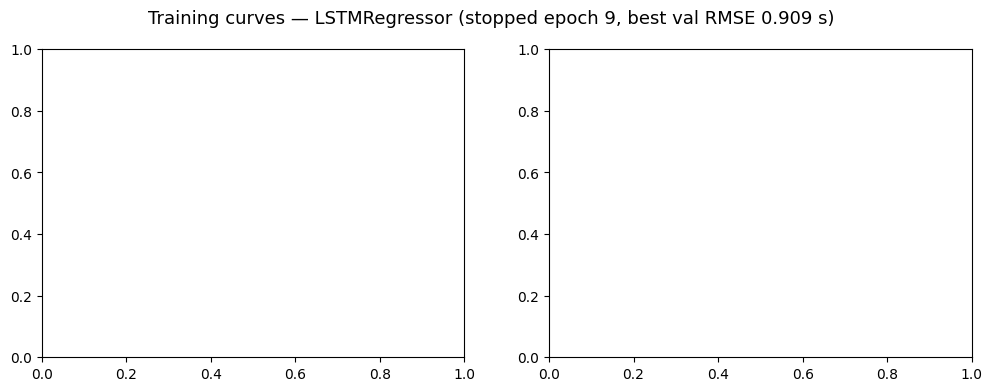

In [98]:
# ── training curves ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"Training curves — {model.__class__.__name__} "
    f"(stopped epoch {stopped_epoch}, best val RMSE {best_val_rmse:.3f} s)",
    fontsize=13,
)

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train loss (MSE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()
axes[0].set_title("Training loss")

if "val_mae" in history_df.columns:
    axes[1].plot(history_df["epoch"], history_df["val_mae"],  label="val MAE")
    axes[1].plot(history_df["epoch"], history_df["val_rmse"], label="val RMSE")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Seconds"); axes[1].legend()
    axes[1].set_title("Validation metrics")
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()